# Logistic  Regression

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import pickle


In [4]:
df = pd.read_csv("data.csv")

df.head()

,SNo,X_1,X_2,y
0,0,-0.869144,0.389310,0.0
1,1,-0.993467,-0.610591,0.0
2,2,-0.834064,0.239236,0.0
3,3,-0.136471,0.632003,1.0
4,4,0.403887,0.310784,1.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SNo     100 non-null    int64  
 1   X_1     100 non-null    float64
 2   X_2     100 non-null    float64
 3   y       100 non-null    float64
dtypes: float64(3), int64(1)
memory usage: 3.3 KB


In [6]:
df.describe()

,SNo,X_1,X_2,y
count,100.000000,100.000000,100.000000,100.000000
mean,49.500000,0.020093,0.043525,0.600000
std,29.011492,0.557790,0.544421,0.492366
min,0.000000,-1.000000,-1.000000,0.000000
25%,24.750000,-0.402007,-0.485076,0.000000
50%,49.500000,0.059902,0.086310,1.000000
75%,74.250000,0.437707,0.428448,1.000000
max,99.000000,1.000000,1.000000,1.000000


In [7]:
df.shape


(100, 4)

In [8]:
df.isnull().sum()

SNo    0
X_1    0
X_2    0
y      0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df = df.drop("SNo", axis=1)

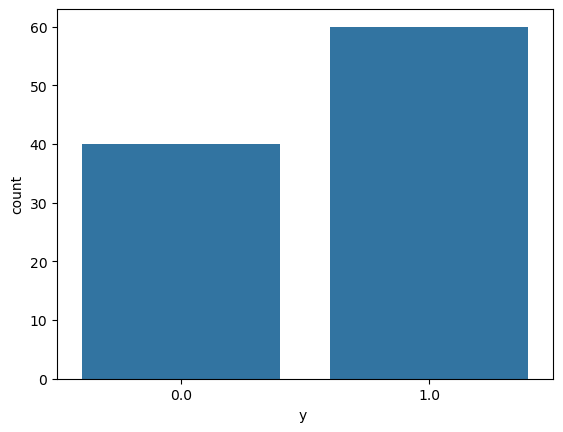

In [11]:
sns.countplot(x='y ',data=df)
plt.show()


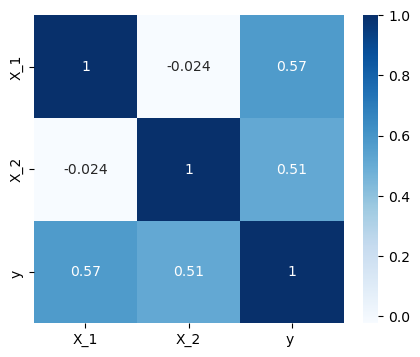

In [12]:
plt.figure(figsize=(5,4))
sns.heatmap(df.corr(),annot=True,cmap="Blues")
plt.show()

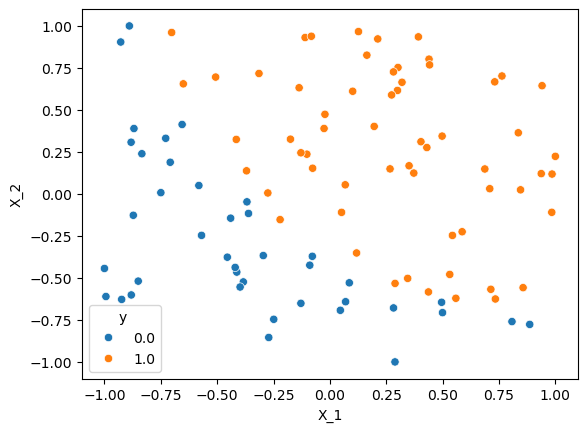

In [13]:
sns.scatterplot(data=df,x='X_1',y='X_2',hue='y ')
plt.show()

In [14]:
X = df[['X_1','X_2']]

y = df['y ']

In [15]:
X.head()

,X_1,X_2
0,-0.869144,0.389310
1,-0.993467,-0.610591
2,-0.834064,0.239236
3,-0.136471,0.632003
4,0.403887,0.310784


In [16]:
y.head()

0    0.0
1    0.0
2    0.0
3    1.0
4    1.0
Name: y , dtype: float64

In [17]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [18]:
print(X_train.shape)
print(X_test.shape)

(80, 2)
(20, 2)


In [19]:
model = LogisticRegression()

In [20]:
model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [21]:
y_pred = model.predict(X_test)

In [22]:
print(y_pred)

[0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1.]


In [23]:
accuracy = accuracy_score(y_test,y_pred)

print("Accuracy :",accuracy)

Accuracy : 0.85


In [24]:
precision = precision_score(y_test,y_pred)

print("Precision :",precision)

Precision : 0.9090909090909091


In [25]:
recall = recall_score(y_test,y_pred)

print("Recall :",recall)

Recall : 0.8333333333333334


In [26]:
f1 = f1_score(y_test,y_pred)

print("F1 Score :",f1)

F1 Score : 0.8695652173913043


In [27]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         0.0       0.78      0.88      0.82         8
         1.0       0.91      0.83      0.87        12

    accuracy                           0.85        20
   macro avg       0.84      0.85      0.85        20
weighted avg       0.86      0.85      0.85        20



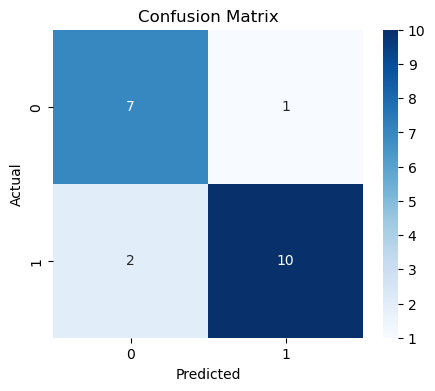

In [28]:
cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [29]:
with open("model.pkl","wb") as file:
    pickle.dump(model,file)

print("Model Saved Successfully")

Model Saved Successfully
